In [184]:
import warnings
warnings.filterwarnings('ignore')

In [185]:
# Import Libraries 
import pandas as pd
import numpy as np

In [186]:
 #Reading the dataset 
dataset = pd.read_csv( "day bikes.csv" )

In [187]:
dataset.head( )

,_id,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,63fcb64c7947cd2ea96ca9f7,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,63fcb64c7947cd2ea96ca9f8,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,63fcb64c7947cd2ea96ca9fb,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
3,63fcb64c7947cd2ea96ca9fc,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
4,63fcb64c7947cd2ea96caa02,12,2011-01-12,1,0,1,0,3,1,1,0.172727,0.160473,0.599545,0.304627,25,1137,1162


In [188]:
dataset.shape

(731, 17)

In [189]:
dataset.columns

Index(['_id', 'instant', 'dteday', 'season', 'yr', 'mnth', 'holiday',
       'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum',
       'windspeed', 'casual', 'registered', 'cnt'],
      dtype='object')

In [190]:
 dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   _id         731 non-null    object 
 1   instant     731 non-null    int64  
 2   dteday      731 non-null    object 
 3   season      731 non-null    int64  
 4   yr          731 non-null    int64  
 5   mnth        731 non-null    int64  
 6   holiday     731 non-null    int64  
 7   weekday     731 non-null    int64  
 8   workingday  731 non-null    int64  
 9   weathersit  731 non-null    int64  
 10  temp        731 non-null    float64
 11  atemp       731 non-null    float64
 12  hum         731 non-null    float64
 13  windspeed   731 non-null    float64
 14  casual      731 non-null    int64  
 15  registered  731 non-null    int64  
 16  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(2)
memory usage: 97.2+ KB


In [191]:
#assigning string values to diff seasons instead of numeric values 

#1 - spring 
dataset.loc[(dataset[ 'season' ]==1), ' season ' ] = ' spring ' 

#2 - summer 
 
dataset.loc[(dataset[ 'season' ]==2), ' season ' ] = ' summer ' 

#3 - fall 

dataset.loc[(dataset[ 'season' ]== 3 ), ' season ' ] = ' fall ' 

#4 - winter 

dataset.loc[(dataset[ 'season' ]==4), ' season ' ] = ' winter '


In [192]:
 dataset['season'].astype('category').value_counts( )

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

In [193]:
 # 0 = 2011 , 1= 2012 : year
dataset['yr'].astype('category').value_counts( )

yr
1    366
0    365
Name: count, dtype: int64

In [194]:
#assigning string values to diff months instead of numeric values

def object_map_mnths(x):
 return x.map({1: 'Jan' , 2: 'Feb' , 3: 'Mar',4: 'Apr', 5:'May' , 6:' Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov' ,12:'Dec'})

In [195]:
 dataset[['mnth']] = dataset [['mnth']].apply(object_map_mnths)

In [196]:
 dataset['mnth'].astype('category').value_counts( )

mnth
Aug     62
Dec     62
Jan     62
Jul     62
Mar     62
May     62
Oct     62
 Jun    60
Apr     60
Nov     60
Sep     60
Feb     57
Name: count, dtype: int64

In [197]:
dataset['holiday'].astype('category').value_counts( )

holiday
0    710
1     21
Name: count, dtype: int64

In [205]:
def str_map_weekday(x):
    return x.map({1:'Mon' , 2:'Tues' ,  3 :'Wed' , 4:' Thurs' , 5 : 'Fri' , 6 :' Sat' , 0 : 'Sun'})

In [206]:
mapping = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

dataset['weekday'] = dataset['weekday'].map(mapping)

In [208]:
dataset['weekday'].astype('category').value_counts()

weekday
Monday       105
Sunday       105
Tuesday      105
Friday       104
Saturday     104
Thursday     104
Wednesday    104
Name: count, dtype: int64

In [211]:
dataset['workingday'].astype( 'category').value_counts( )

workingday
1    500
0    231
Name: count, dtype: int64

In [212]:
 #1 - clear , few clouds , partly cloudy 

dataset.loc[(dataset['weathersit' ] ==1) , 'weathersit' ] = ' A ' 

# 2 = mist , cloudy 
dataset.loc[(dataset['weathersit' ] ==2), ' weathersit' ] = 'B' 

#3 - light snow , heavy rain 

dataset.loc[(dataset['weathersit' ] ==3), ' weathersit' ] = 'C'

In [215]:
dataset['weathersit'].astype('category').value_counts( )

weathersit
 A     463
2      247
3       21
Name: count, dtype: int64

In [216]:
 # Importing libs 
import matplotlib.pyplot as  plt
import seaborn as sns

<Axes: xlabel='temp', ylabel='Density'>

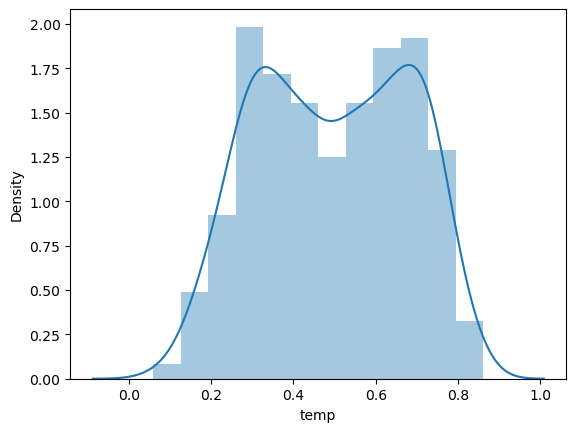

In [218]:
 # temperature
sns.distplot ( dataset [ 'temp'])

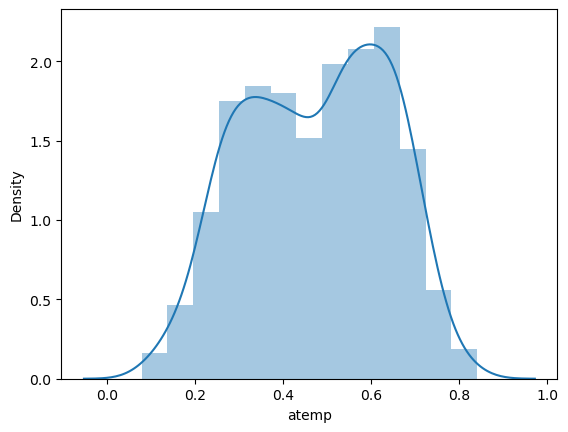

In [219]:
 # actual temperature
sns.distplot ( dataset [ 'atemp'])
plt.show ( )

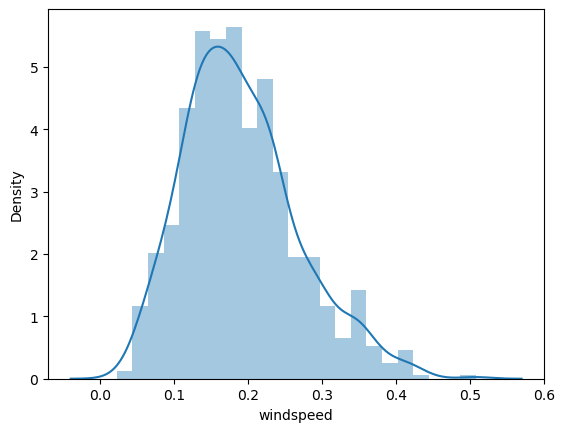

In [220]:
 # windspeed 
sns.distplot ( dataset [ 'windspeed'])
plt.show ( )

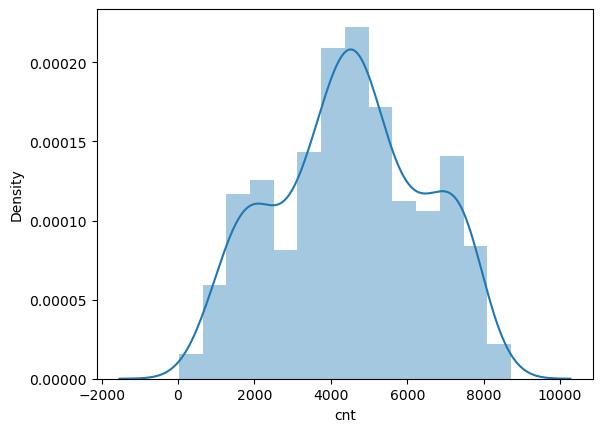

In [221]:
 # target variable : count of total rental bikes including both casual and registered

sns.distplot ( dataset [ 'cnt'])
plt.show ( )

In [224]:
dataset['dteday'] = dataset['dteday'].astype('datetime64[ns]')

In [225]:
dataset_categorical = dataset.select_dtypes(exclude=['float64', 'datetime64[ns]', 'int64'])

In [226]:
 dataset_categorical.columns

Index(['_id', 'mnth', 'weekday', 'weathersit', ' season ', ' weathersit'], dtype='object')

In [227]:
dataset_categorical

,_id,mnth,weekday,weathersit,season,weathersit
0,63fcb64c7947cd2ea96ca9f7,Jan,Sunday,2,spring,B
1,63fcb64c7947cd2ea96ca9f8,Jan,Monday,2,spring,B
2,63fcb64c7947cd2ea96ca9fb,Jan,Thursday,A,spring,NaN
3,63fcb64c7947cd2ea96ca9fc,Jan,Friday,A,spring,NaN
4,63fcb64c7947cd2ea96caa02,Jan,Thursday,A,spring,NaN
...,...,...,...,...,...,...
726,63fcb64c7947cd2ea96cacae,Nov,Tuesday,A,winter,NaN
727,63fcb64c7947cd2ea96cacb5,Dec,Tuesday,A,winter,NaN
728,63fcb64c7947cd2ea96cacc4,Dec,Wednesday,A,winter,NaN
729,63fcb64c7947cd2ea96cacc5,Dec,Thursday,A,winter,NaN


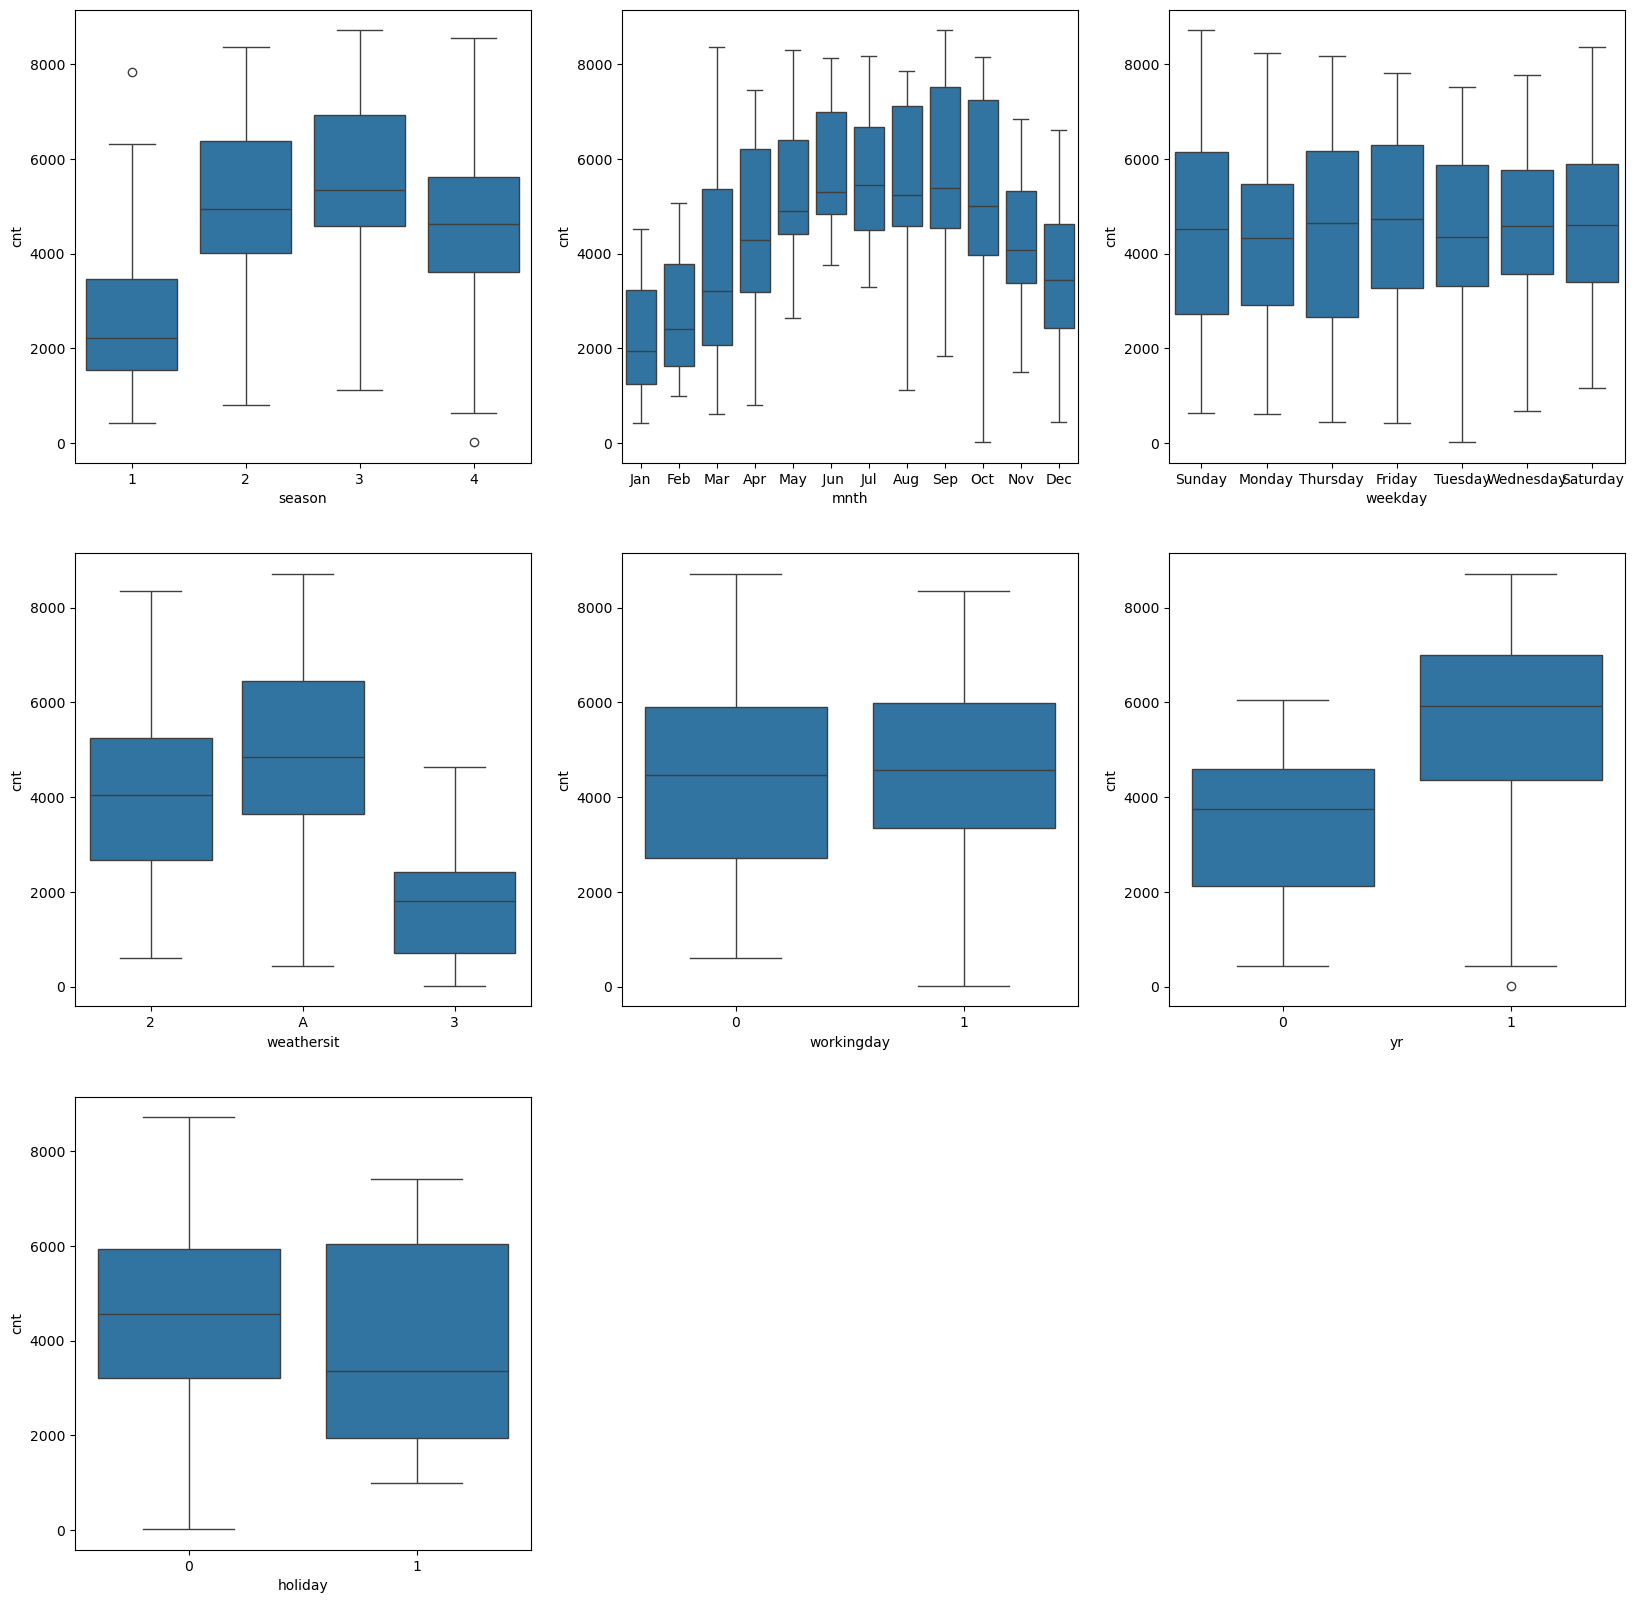

In [229]:
plt.figure(figsize=(20,20))
plt.subplot(3,3,1)
sns.boxplot( x = 'season' , y = 'cnt' , data = dataset) 
plt.subplot(3,3,2)
sns.boxplot( x = 'mnth' , y = 'cnt' , data = dataset) 
plt.subplot(3,3,3)
sns.boxplot( x = 'weekday' , y = 'cnt' , data = dataset) 
plt.subplot(3,3,4)
sns.boxplot( x = 'weathersit' , y = 'cnt' , data = dataset) 
plt.subplot(3,3,5)
sns.boxplot( x = 'workingday' , y = 'cnt' , data = dataset) 
plt.subplot(3,3,6)
sns.boxplot( x = 'yr' , y = 'cnt' , data = dataset)
plt.subplot(3,3,7)
sns.boxplot( x = 'holiday', y ='cnt' , data = dataset) 
plt.show( )

In [230]:
intVarlist = ["casual" , "registered" , "cnt" ] 

for var in intVarlist : 
    dataset [var] = dataset[var ].astype("float")

In [231]:
dataset_numeric = dataset.select_dtypes( include = ['float64']) 
dataset_numeric.head( )

,temp,atemp,hum,windspeed,casual,registered,cnt
0,0.344167,0.363625,0.805833,0.160446,331.0,654.0,985.0
1,0.363478,0.353739,0.696087,0.248539,131.0,670.0,801.0
2,0.226957,0.229270,0.436957,0.186900,82.0,1518.0,1600.0
3,0.204348,0.233209,0.518261,0.089565,88.0,1518.0,1606.0
4,0.172727,0.160473,0.599545,0.304627,25.0,1137.0,1162.0


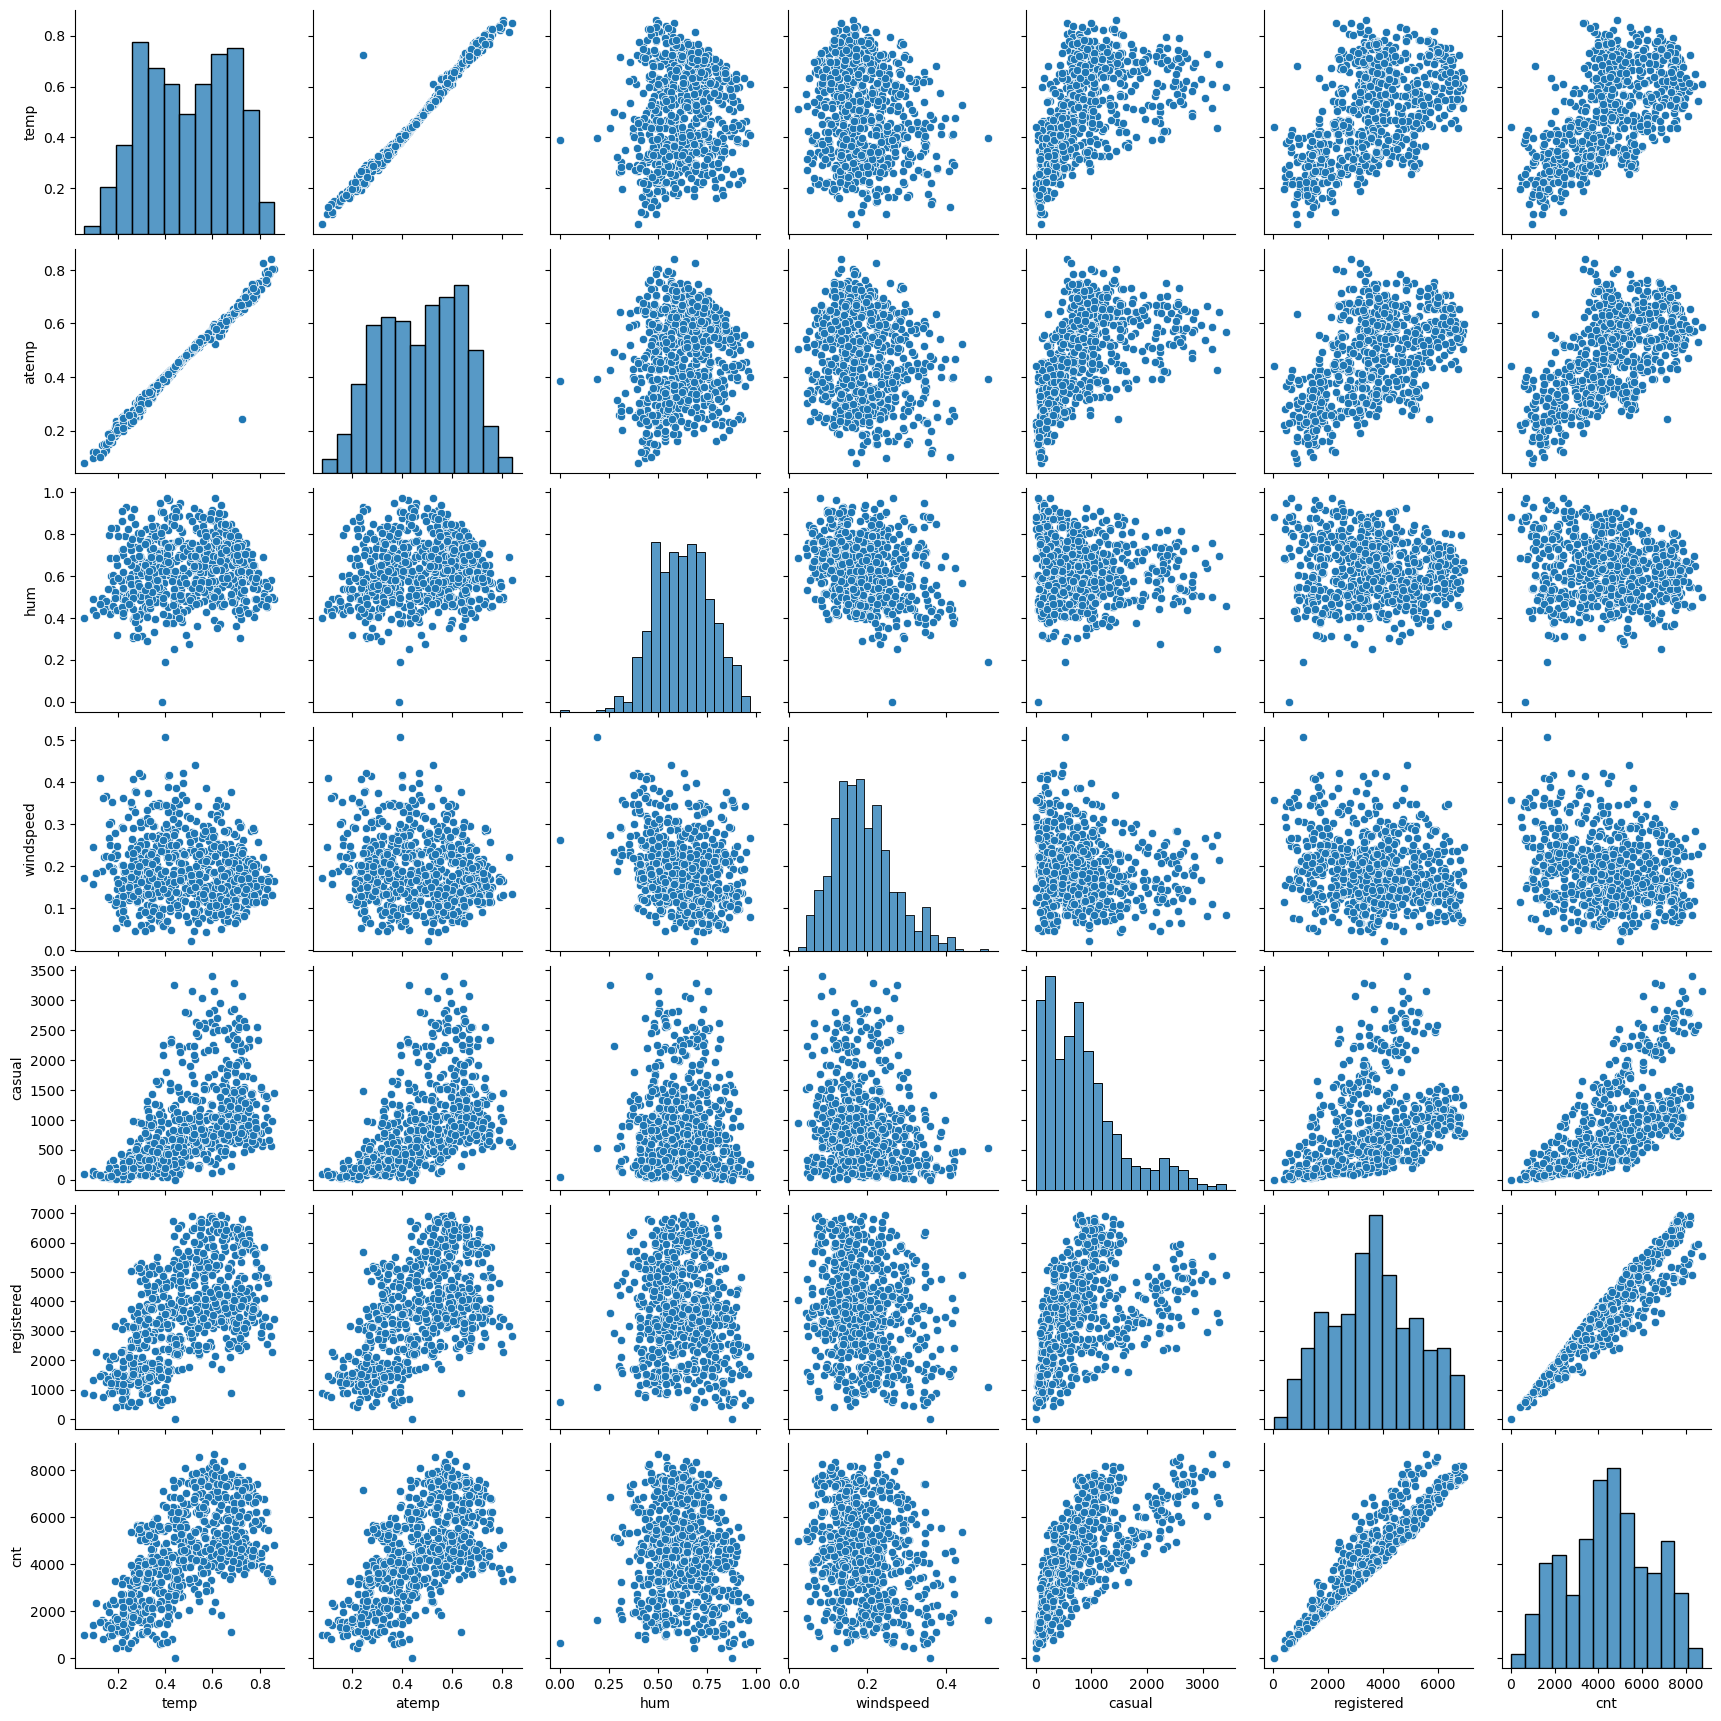

In [232]:
sns.pairplot(dataset_numeric ) 
plt.show( )

In [233]:
cor = dataset_numeric.corr( ) 
cor

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.991702,0.126963,-0.157944,0.543285,0.540012,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,0.543864,0.544192,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,-0.077008,-0.091089,-0.100659
windspeed,-0.157944,-0.183643,-0.248489,1.000000,-0.167613,-0.217449,-0.234545
casual,0.543285,0.543864,-0.077008,-0.167613,1.000000,0.395282,0.672804
registered,0.540012,0.544192,-0.091089,-0.217449,0.395282,1.000000,0.945517
cnt,0.627494,0.631066,-0.100659,-0.234545,0.672804,0.945517,1.000000


<Axes: >

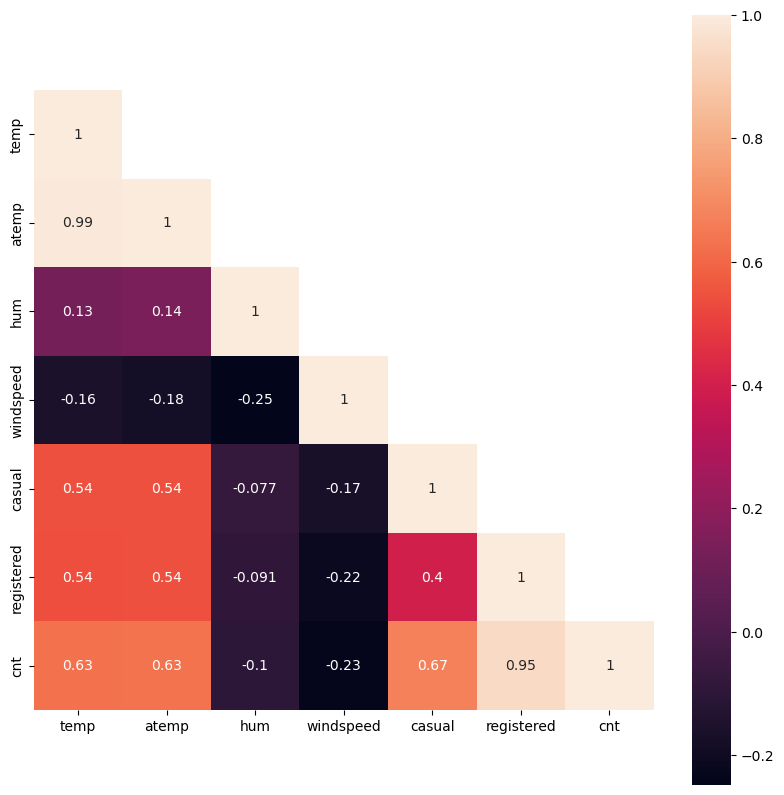

In [236]:
# Heat map 
mask = np.array(cor)
mask[np.tril_indices_from(mask)] = False

fig, ax = plt.subplots()
fig.set_size_inches(10, 10)

sns.heatmap(cor, mask=mask, vmax=1, square=True, annot=True)

In [238]:
 # removing attempt  as it is highly correlated with temp 
dataset.drop('atemp' , axis =1 , inplace = True )

In [239]:
dataset.head( )

,_id,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt,season,weathersit
0,63fcb64c7947cd2ea96ca9f7,1,2011-01-01,1,0,Jan,0,Sunday,0,2,0.344167,0.805833,0.160446,331.0,654.0,985.0,spring,B
1,63fcb64c7947cd2ea96ca9f8,2,2011-01-02,1,0,Jan,0,Monday,0,2,0.363478,0.696087,0.248539,131.0,670.0,801.0,spring,B
2,63fcb64c7947cd2ea96ca9fb,5,2011-01-05,1,0,Jan,0,Thursday,1,A,0.226957,0.436957,0.186900,82.0,1518.0,1600.0,spring,NaN
3,63fcb64c7947cd2ea96ca9fc,6,2011-01-06,1,0,Jan,0,Friday,1,A,0.204348,0.518261,0.089565,88.0,1518.0,1606.0,spring,NaN
4,63fcb64c7947cd2ea96caa02,12,2011-01-12,1,0,Jan,0,Thursday,1,A,0.172727,0.599545,0.304627,25.0,1137.0,1162.0,spring,NaN


In [240]:
dataset_categorical = dataset.select_dtypes(include=['object'])

In [243]:
dataset_categorical.head()

,_id,mnth,weekday,weathersit,season,weathersit
0,63fcb64c7947cd2ea96ca9f7,Jan,Sunday,2,spring,B
1,63fcb64c7947cd2ea96ca9f8,Jan,Monday,2,spring,B
2,63fcb64c7947cd2ea96ca9fb,Jan,Thursday,A,spring,NaN
3,63fcb64c7947cd2ea96ca9fc,Jan,Friday,A,spring,NaN
4,63fcb64c7947cd2ea96caa02,Jan,Thursday,A,spring,NaN


In [245]:
dataset_dummies = pd.get_dummies(dataset_categorical, drop_first=True)

dataset_dummies.head()

,_id_63fcb64c7947cd2ea96ca9f8,_id_63fcb64c7947cd2ea96ca9f9,_id_63fcb64c7947cd2ea96ca9fa,_id_63fcb64c7947cd2ea96ca9fb,_id_63fcb64c7947cd2ea96ca9fc,_id_63fcb64c7947cd2ea96ca9fd,_id_63fcb64c7947cd2ea96ca9fe,_id_63fcb64c7947cd2ea96ca9ff,_id_63fcb64c7947cd2ea96caa00,_id_63fcb64c7947cd2ea96caa01,...,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_3,weathersit_ A,season _ spring,season _ summer,season _ winter,weathersit_C
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,True,True,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,True,False,False,False


In [246]:
# Drop categorical variables columns 

dataset= dataset.drop(list(dataset_categorical.columns), axis=1) 

dataset

,instant,dteday,season,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,0,0,0.344167,0.805833,0.160446,331.0,654.0,985.0
1,2,2011-01-02,1,0,0,0,0.363478,0.696087,0.248539,131.0,670.0,801.0
2,5,2011-01-05,1,0,0,1,0.226957,0.436957,0.186900,82.0,1518.0,1600.0
3,6,2011-01-06,1,0,0,1,0.204348,0.518261,0.089565,88.0,1518.0,1606.0
4,12,2011-01-12,1,0,0,1,0.172727,0.599545,0.304627,25.0,1137.0,1162.0
...,...,...,...,...,...,...,...,...,...,...,...,...
726,696,2012-11-26,4,1,0,1,0.313333,0.535417,0.046650,337.0,4750.0,5087.0
727,703,2012-12-03,4,1,0,1,0.452500,0.767500,0.082721,555.0,5679.0,6234.0
728,718,2012-12-18,4,1,0,1,0.410833,0.666250,0.221404,433.0,5124.0,5557.0
729,719,2012-12-19,4,1,0,1,0.332500,0.625417,0.184092,333.0,4934.0,5267.0


In [249]:
# concatenate data variables with the dataset 
dataset = pd.concat([dataset, dataset_dummies], axis=1)


In [252]:
dataset

,instant,dteday,season,yr,holiday,workingday,temp,hum,windspeed,casual,...,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_3,weathersit_ A,season _ spring,season _ summer,season _ winter,weathersit_C
0,1,2011-01-01,1,0,0,0,0.344167,0.805833,0.160446,331.0,...,True,False,False,False,False,False,True,False,False,False
1,2,2011-01-02,1,0,0,0,0.363478,0.696087,0.248539,131.0,...,False,False,False,False,False,False,True,False,False,False
2,5,2011-01-05,1,0,0,1,0.226957,0.436957,0.186900,82.0,...,False,True,False,False,False,True,True,False,False,False
3,6,2011-01-06,1,0,0,1,0.204348,0.518261,0.089565,88.0,...,False,False,False,False,False,True,True,False,False,False
4,12,2011-01-12,1,0,0,1,0.172727,0.599545,0.304627,25.0,...,False,True,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,696,2012-11-26,4,1,0,1,0.313333,0.535417,0.046650,337.0,...,False,False,True,False,False,True,False,False,True,False
727,703,2012-12-03,4,1,0,1,0.452500,0.767500,0.082721,555.0,...,False,False,True,False,False,True,False,False,True,False
728,718,2012-12-18,4,1,0,1,0.410833,0.666250,0.221404,433.0,...,False,False,False,True,False,True,False,False,True,False
729,719,2012-12-19,4,1,0,1,0.332500,0.625417,0.184092,333.0,...,False,True,False,False,False,True,False,False,True,False


In [254]:
dataset = dataset.drop(['instant' , 'dteday' ], axis = 1 , inplace=False) 

dataset.head()

,season,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt,...,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_3,weathersit_ A,season _ spring,season _ summer,season _ winter,weathersit_C
0,1,0,0,0,0.344167,0.805833,0.160446,331.0,654.0,985.0,...,True,False,False,False,False,False,True,False,False,False
1,1,0,0,0,0.363478,0.696087,0.248539,131.0,670.0,801.0,...,False,False,False,False,False,False,True,False,False,False
2,1,0,0,1,0.226957,0.436957,0.186900,82.0,1518.0,1600.0,...,False,True,False,False,False,True,True,False,False,False
3,1,0,0,1,0.204348,0.518261,0.089565,88.0,1518.0,1606.0,...,False,False,False,False,False,True,True,False,False,False
4,1,0,0,1,0.172727,0.599545,0.304627,25.0,1137.0,1162.0,...,False,True,False,False,False,True,True,False,False,False


In [255]:
#Import libs 
from sklearn import linear_model 
from sklearn.linear_model import LinearRegression

In [257]:
# Split the dataframe into train and test datasets 

from sklearn.model_selection import train_test_split

np.random.seed(0)

df_train, df_test = train_test_split(dataset, train_size=0.7, test_size=0.3, random_state=100)

In [258]:
df_train

,season,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt,...,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_3,weathersit_ A,season _ spring,season _ summer,season _ winter,weathersit_C
576,4,0,0,0,0.329167,0.502083,0.224496,943.0,2720.0,3663.0,...,True,False,False,False,False,True,False,False,True,False
426,1,0,0,1,0.203478,0.793043,0.123300,38.0,1129.0,1167.0,...,False,False,False,False,False,False,True,False,False,False
729,4,1,0,1,0.332500,0.625417,0.184092,333.0,4934.0,5267.0,...,False,True,False,False,False,True,False,False,True,False
482,2,1,1,0,0.664167,0.561667,0.284829,1198.0,5172.0,6370.0,...,False,False,True,False,False,True,False,True,False,False
111,4,0,0,1,0.317500,0.663750,0.060958,178.0,3562.0,3740.0,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,4,0,0,1,0.410000,0.970417,0.266175,50.0,655.0,705.0,...,False,True,False,False,True,False,False,False,True,True
53,1,1,0,1,0.313333,0.526667,0.178496,310.0,3841.0,4151.0,...,False,False,False,False,False,True,True,False,False,False
350,4,1,0,1,0.352174,0.333478,0.347835,340.0,4975.0,5315.0,...,False,False,False,False,False,True,False,False,True,False
79,2,0,0,0,0.253043,0.493913,0.184300,472.0,1221.0,1693.0,...,False,False,False,False,False,False,False,True,False,False


In [8]:
from sklearn.preprocessing import MinMaxScaler

In [9]:
scaler = MinMaxScaler()

In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df_train = pd.read_csv("day bikes.csv")  
print(df_train.head())

scaler = StandardScaler()

var = ["temp", "hum", "windspeed", "casual", "registered", "cnt"]

df_train[var] = scaler.fit_transform(df_train[var])

print(df_train.head())

                        _id  instant      dteday  season  yr  mnth  holiday  \
0  63fcb64c7947cd2ea96ca9f7        1  2011-01-01       1   0     1        0   
1  63fcb64c7947cd2ea96ca9f8        2  2011-01-02       1   0     1        0   
2  63fcb64c7947cd2ea96ca9fb        5  2011-01-05       1   0     1        0   
3  63fcb64c7947cd2ea96ca9fc        6  2011-01-06       1   0     1        0   
4  63fcb64c7947cd2ea96caa02       12  2011-01-12       1   0     1        0   

   weekday  workingday  weathersit      temp     atemp       hum  windspeed  \
0        6           0           2  0.344167  0.363625  0.805833   0.160446   
1        0           0           2  0.363478  0.353739  0.696087   0.248539   
2        3           1           1  0.226957  0.229270  0.436957   0.186900   
3        4           1           1  0.204348  0.233209  0.518261   0.089565   
4        3           1           1  0.172727  0.160473  0.599545   0.304627   

   casual  registered   cnt  
0     331         65

In [43]:
 df_train.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,7.310000e+02,731.000000,7.310000e+02,7.310000e+02,7.310000e+02,7.310000e+02,7.310000e+02
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,-4.009561e-16,0.474354,-2.138432e-16,-1.968330e-16,8.748132e-17,7.776117e-17,-5.346081e-17
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,1.000685e+00,0.162961,1.000685e+00,1.000685e+00,1.000685e+00,1.000685e+00,1.000685e+00
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,-2.384871e+00,0.079070,-4.411486e+00,-2.170506e+00,-1.233219e+00,-2.332092e+00,-2.315399e+00
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,-8.653855e-01,0.337842,-7.580469e-01,-7.171066e-01,-7.763235e-01,-7.434458e-01,-6.985684e-01
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,1.611698e-02,0.486733,-8.621154e-03,-1.228127e-01,-1.970064e-01,3.737606e-03,2.254842e-02
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,8.748452e-01,0.608602,7.188453e-01,5.517254e-01,3.611784e-01,7.185324e-01,7.498640e-01
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,2.002355e+00,0.840896,2.421148e+00,4.092936e+00,3.733606e+00,2.109961e+00,2.174535e+00


In [149]:
scaler = StandardScaler()

df_train[numeric_cols] = scaler.fit_transform(df_train[numeric_cols])

print(df_train.head())

plt.figure(figsize=(12, 10))
sns.heatmap(df_train.corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

                        _id  instant      dteday  season  yr  mnth  holiday  \
0  63fcb64c7947cd2ea96ca9f7        1  2011-01-01       1   0     1        0   
1  63fcb64c7947cd2ea96ca9f8        2  2011-01-02       1   0     1        0   
2  63fcb64c7947cd2ea96ca9fb        5  2011-01-05       1   0     1        0   
3  63fcb64c7947cd2ea96ca9fc        6  2011-01-06       1   0     1        0   
4  63fcb64c7947cd2ea96caa02       12  2011-01-12       1   0     1        0   

   weekday  workingday  weathersit      temp     atemp       hum  windspeed  \
0        6           0           2 -0.826662  0.363625  1.250171  -0.387892   
1        0           0           2 -0.721095  0.353739  0.479113   0.749602   
2        3           1           1 -1.467414  0.229270 -1.341494  -0.046307   
3        4           1           1 -1.591011  0.233209 -0.770265  -1.303134   
4        3           1           1 -1.763873  0.160473 -0.199176   1.473833   

     casual  registered       cnt  
0 -0.753734   

ValueError: could not convert string to float: '63fcb64c7947cd2ea96ca9f7'

<Figure size 1200x1000 with 0 Axes>

In [55]:
#Diving into X and Y 

y_train = df_train.pop('cnt')

x_train = df_train.drop(["casual" , "registered"], axis =1)

In [56]:
 x_train.head()

,_id,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,63fcb64c7947cd2ea96ca9f7,1,2011-01-01,1,0,1,0,6,0,2,-0.826662,0.363625,1.250171,-0.387892
1,63fcb64c7947cd2ea96ca9f8,2,2011-01-02,1,0,1,0,0,0,2,-0.721095,0.353739,0.479113,0.749602
2,63fcb64c7947cd2ea96ca9fb,5,2011-01-05,1,0,1,0,3,1,1,-1.467414,0.229270,-1.341494,-0.046307
3,63fcb64c7947cd2ea96ca9fc,6,2011-01-06,1,0,1,0,4,1,1,-1.591011,0.233209,-0.770265,-1.303134
4,63fcb64c7947cd2ea96caa02,12,2011-01-12,1,0,1,0,3,1,1,-1.763873,0.160473,-0.199176,1.473833


In [59]:
import numpy as np

np_array = np.asarray(df_train)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     207.2
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           4.26e-97
Time:                        00:13:45   Log-Likelihood:                -6343.9
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     727   BIC:                         1.271e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4504.3488     52.717     85.444      0.0

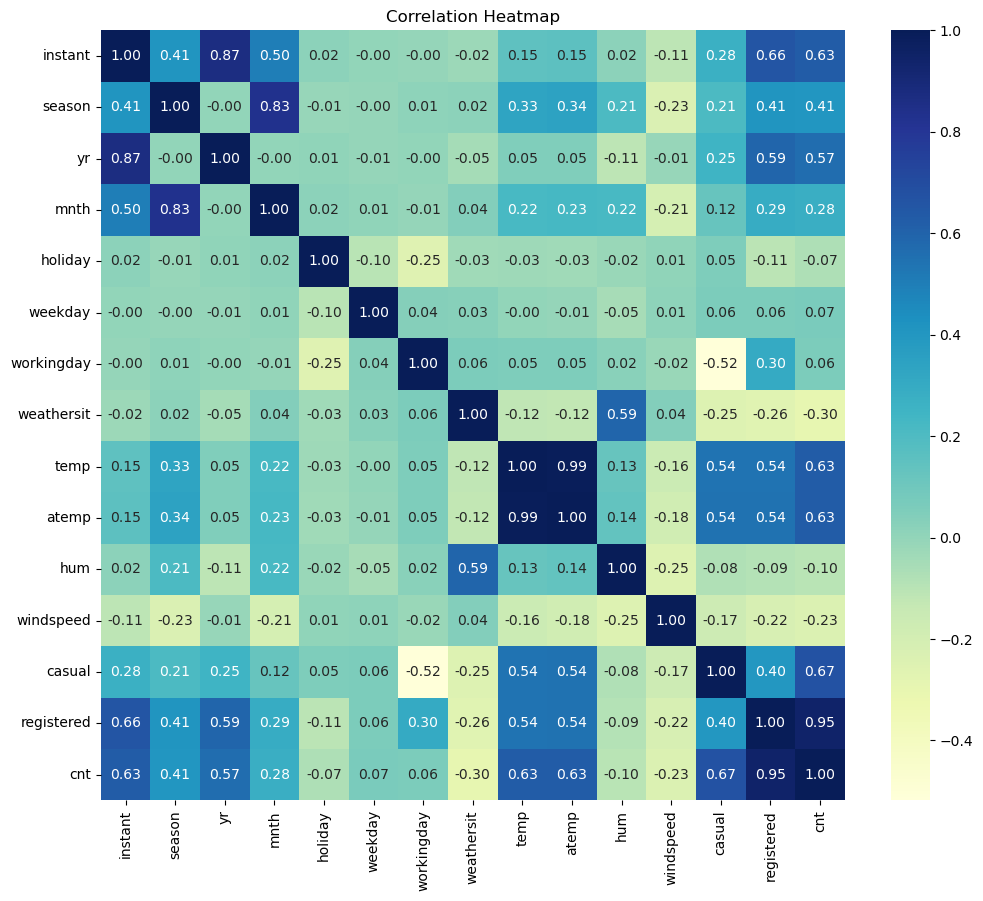

In [64]:
feature_cols = ["temp", "hum", "windspeed"]  # Features
target_col = "cnt"                             # Target

X = df_train[feature_cols]
y = df_train[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = np.asarray(X_scaled, dtype=float)
y = np.asarray(y, dtype=float)

X_scaled_const = sm.add_constant(X_scaled)

lr = sm.OLS(y, X_scaled_const).fit()

print(lr.summary())

plt.figure(figsize=(12, 10))
sns.heatmap(df_train.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [65]:
x_train_lm

,const,_id,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1.0,63fcb64c7947cd2ea96ca9f7,1,2011-01-01,1,0,1,0,6,0,2,-0.826662,0.363625,1.250171,-0.387892
1,1.0,63fcb64c7947cd2ea96ca9f8,2,2011-01-02,1,0,1,0,0,0,2,-0.721095,0.353739,0.479113,0.749602
2,1.0,63fcb64c7947cd2ea96ca9fb,5,2011-01-05,1,0,1,0,3,1,1,-1.467414,0.229270,-1.341494,-0.046307
3,1.0,63fcb64c7947cd2ea96ca9fc,6,2011-01-06,1,0,1,0,4,1,1,-1.591011,0.233209,-0.770265,-1.303134
4,1.0,63fcb64c7947cd2ea96caa02,12,2011-01-12,1,0,1,0,3,1,1,-1.763873,0.160473,-0.199176,1.473833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1.0,63fcb64c7947cd2ea96cacae,696,2012-11-26,4,1,11,0,1,1,1,-0.995222,0.339004,-0.649729,-1.857273
727,1.0,63fcb64c7947cd2ea96cacb5,703,2012-12-03,4,1,12,0,1,1,1,-0.234438,0.455796,0.980850,-1.391512
728,1.0,63fcb64c7947cd2ea96cacc4,718,2012-12-18,4,1,12,0,2,1,1,-0.462219,0.409708,0.269483,0.399223
729,1.0,63fcb64c7947cd2ea96cacc5,719,2012-12-19,4,1,12,0,3,1,1,-0.890442,0.342162,-0.017403,-0.082565


In [66]:
 lr.params

array([4504.34883721, 1211.98052273, -441.24561333, -372.2718937 ])

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

lm = LinearRegression()
lm.fit(x_train, y_train)

print("Coefficients:", lm.coef_)
print("Intercept:", lm.intercept_)

y_pred = lm.predict(x_test)
print("First 5 predictions:", y_pred[:5])

Coefficients: [1198.86111732 -462.07207002 -364.57535544]
Intercept: 4508.842692754319
First 5 predictions: [5860.65978966 5185.21218443 5328.17005058 6017.69699386 6401.53556609]


In [72]:
print(lm.coef_)
print(lm.intercept_)

[1198.86111732 -462.07207002 -364.57535544]
4508.842692754319


In [73]:
lr.summary( )

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     207.2
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           4.26e-97
Time:                        00:16:10   Log-Likelihood:                -6343.9
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     727   BIC:                         1.271e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4504.3488     52.717     85.444      0.000    4400.853    4607.844
x1          1211.9805     53.613     22.606      0.000    1106.726    1317.235
x2          -441.2456     54.654     -8.073      0.000    -548.544    -333.947
x3          -372.2719     54.901     -6.781      0.000    -480.055    -264.489
==============================================================================
Omnibus:                       11.001   Durbin-Watson:                   0.666
Prob(Omnibus):                  0.004   Jarque-Bera (JB):                8.213
Skew:                           0.152   Prob(JB):                       0.0165
Kurtosis:                       2.579   Cond. No.                         1.35
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [74]:
 # import rfe

from sklearn.feature_selection import RFE

In [77]:
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

lm = LinearRegression()
n_features = 15
if n_features > X.shape[1]:
    n_features = X.shape[1]  
rfe1 = RFE(lm, n_features_to_select=n_features)

rfe1.fit(x_train, y_train)

print("Selected features (True = selected):", rfe1.support_)
print("Feature ranking (1 = selected):", rfe1.ranking_)

Selected features (True = selected): [ True  True  True]
Feature ranking (1 = selected): [1 1 1]


In [81]:
X = df[feature_cols] 
y = df['cnt']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)  # keep column names

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

coll = x_train.columns[rfe1.support_]
print("Selected columns:", list(coll))

Selected columns: ['temp', 'hum', 'windspeed']


In [82]:
coll

Index(['temp', 'hum', 'windspeed'], dtype='object')

In [83]:
 x_train_rfe1 = x_train[coll]

In [84]:

x_train_rfe1 = sm.add_constant(x_train_rfe1)

lm1 = sm.OLS(y_train, x_train_rfe1).fit( ) 

lm1.summary( )

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.460
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     164.6
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           3.44e-77
Time:                        00:18:33   Log-Likelihood:                -5063.4
No. Observations:                 584   AIC:                         1.013e+04
Df Residuals:                     580   BIC:                         1.015e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4508.8427     58.550     77.009      0.000    4393.847    4623.838
temp        1198.8611     60.165     19.926      0.000    1080.693    1317.029
hum         -462.0721     62.684     -7.372      0.000    -585.187    -338.958
windspeed   -364.5754     61.239     -5.953      0.000    -484.853    -244.298
==============================================================================
Omnibus:                       17.819   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               12.685
Skew:                           0.247   Prob(JB):                      0.00176
Kurtosis:                       2.474   Cond. No.                         1.36
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [85]:
 from statsmodels.stats.outliers_influence import variance_inflation_factor

In [86]:
 a = x_train_rfe1.drop('const' , axis=1)

In [87]:
#Evaluating VIFs

vif = pd.DataFrame( ) 
vif['features'] = a.columns 

vif['VIF'] =[variance_inflation_factor(a.values , i) for  i in range(a.shape[1])]

vif['VIF'] = round(vif['VIF'] ,2 ) 

vif = vif.sort_values(by = "VIF" , ascending = False) 

vif

,features,VIF
2,windspeed,1.09
1,hum,1.07
0,temp,1.03


In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

lm = LinearRegression()

n_features = 7
rfe2 = RFE(lm, n_features_to_select=n_features)

rfe2.fit(x_train, y_train)

print("Selected features (True = selected):", rfe2.support_)
print("Feature ranking (1 = selected):", rfe2.ranking_)

selected_columns = x_train.columns[rfe2.support_]
print("Selected column names:", list(selected_columns))

Selected features (True = selected): [ True  True  True]
Feature ranking (1 = selected): [1 1 1]
Selected column names: ['temp', 'hum', 'windspeed']


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=7 > n_features=3. There will be no feature selection and all features will be kept.
  warnings.warn(


In [94]:
import statsmodels.api as sm

col2 = x_train.columns[rfe1.support_]
print("Columns selected by RFE1:", list(col2))

x_train_rfe2 = x_train[col2]

x_train_rfe2 = sm.add_constant(x_train_rfe2)

lm2 = sm.OLS(y_train, x_train_rfe2).fit()

print(lm2.summary())

Columns selected by RFE1: ['temp', 'hum', 'windspeed']
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.460
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     164.6
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           3.44e-77
Time:                        00:20:30   Log-Likelihood:                -5063.4
No. Observations:                 584   AIC:                         1.013e+04
Df Residuals:                     580   BIC:                         1.015e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [95]:
# Evaluating VIFs 

b = x_train_rfe2.drop('const', axis =1 ) 

vif1 = pd.DataFrame( ) 
vif1['features'] = b.columns

vif1['VIF' ] = [variance_inflation_factor(b.values, i ) for i in range(b.shape[1])]

vif['VIF'] = round(vif1['VIF'] ,2 ) 

vif1 = vif1.sort_values(by = "VIF" , ascending = False) 

vif1

,features,VIF
2,windspeed,1.093988
1,hum,1.074199
0,temp,1.033117


In [96]:
y_train_cnt = lm2.predict(x_train_rfe2)

C:\Users\HP\AppData\Local\Temp\ipykernel_6584\145269221.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_train, y_train_cnt ), bins =20)


<Axes: ylabel='Density'>

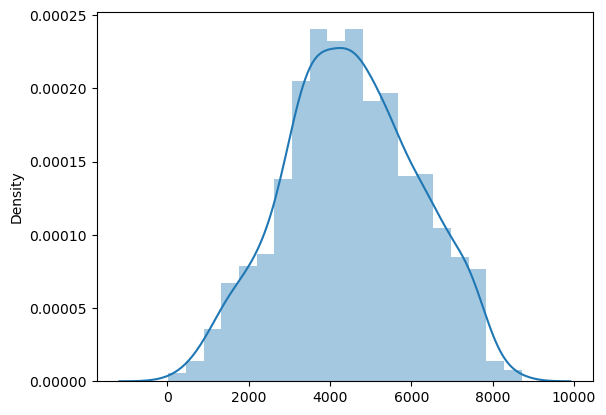

In [99]:
fig = plt.figure ()
sns.distplot((y_train, y_train_cnt ), bins =20)

In [130]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df_train = pd.read_csv("day bikes.csv") 
df_test = pd.read_csv("day bikes.csv")  

var = ["temp", "hum", "windspeed", "casual", "registered", "cnt"]

scaler = StandardScaler()
numeric_var_train = df_train[var].select_dtypes(include=['int64', 'float64']).columns
df_train[numeric_var_train] = scaler.fit_transform(df_train[numeric_var_train])

numeric_var_test = df_test[var].select_dtypes(include=['int64', 'float64']).columns
df_test[numeric_var_test] = scaler.transform(df_test[numeric_var_test])

print(df_test.head())

                        _id  instant      dteday  season  yr  mnth  holiday  \
0  63fcb64c7947cd2ea96ca9f7        1  2011-01-01       1   0     1        0   
1  63fcb64c7947cd2ea96ca9f8        2  2011-01-02       1   0     1        0   
2  63fcb64c7947cd2ea96ca9fb        5  2011-01-05       1   0     1        0   
3  63fcb64c7947cd2ea96ca9fc        6  2011-01-06       1   0     1        0   
4  63fcb64c7947cd2ea96caa02       12  2011-01-12       1   0     1        0   

   weekday  workingday  weathersit      temp     atemp       hum  windspeed  \
0        6           0           2 -0.826662  0.363625  1.250171  -0.387892   
1        0           0           2 -0.721095  0.353739  0.479113   0.749602   
2        3           1           1 -1.467414  0.229270 -1.341494  -0.046307   
3        4           1           1 -1.591011  0.233209 -0.770265  -1.303134   
4        3           1           1 -1.763873  0.160473 -0.199176   1.473833   

     casual  registered       cnt  
0 -0.753734   

In [131]:
y_test = df_test.pop('cnt') 
x_test = df_test.drop(["casual" , "registered" ], axis =1 )

In [132]:
x_test.head()

,_id,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,63fcb64c7947cd2ea96ca9f7,1,2011-01-01,1,0,1,0,6,0,2,-0.826662,0.363625,1.250171,-0.387892
1,63fcb64c7947cd2ea96ca9f8,2,2011-01-02,1,0,1,0,0,0,2,-0.721095,0.353739,0.479113,0.749602
2,63fcb64c7947cd2ea96ca9fb,5,2011-01-05,1,0,1,0,3,1,1,-1.467414,0.229270,-1.341494,-0.046307
3,63fcb64c7947cd2ea96ca9fc,6,2011-01-06,1,0,1,0,4,1,1,-1.591011,0.233209,-0.770265,-1.303134
4,63fcb64c7947cd2ea96caa02,12,2011-01-12,1,0,1,0,3,1,1,-1.763873,0.160473,-0.199176,1.473833


In [133]:
c= x_train_rfe2.drop('const', axis=1 )

In [134]:
col2 = c.columns

In [135]:
 x_test_rfe2 = x_test[col2]

In [136]:
 x_test_rfe2 = sm.add_constant(x_test_rfe2)

In [137]:
x_test_rfe2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   const      731 non-null    float64
 1   temp       731 non-null    float64
 2   hum        731 non-null    float64
 3   windspeed  731 non-null    float64
dtypes: float64(4)
memory usage: 23.0 KB


In [138]:
y_pred = lm2.predict(x_test_rfe2)

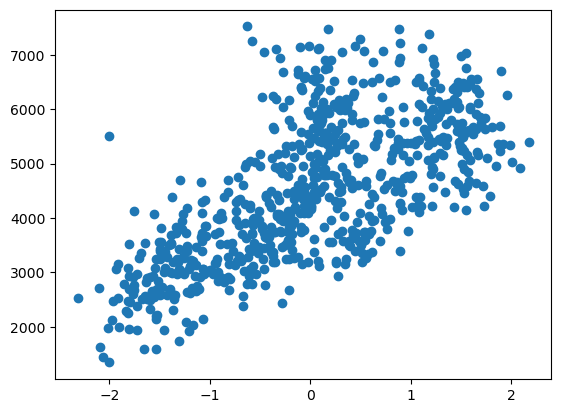

In [139]:
plt.figure()
plt.scatter(y_test, y_pred)

In [140]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

-22025268.686696187

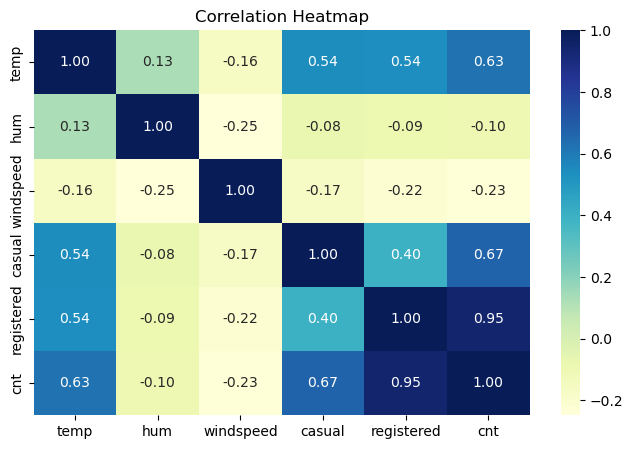

In [148]:
plt.figure(figsize=(8, 5))
sns.heatmap(dataset[col2].corr(), cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()